# BirdCLEF+ 2026 — Phase 3: Head Training on Perch Embeddings

We've replaced the entire "audio → mel → CNN" pipeline with **frozen Perch v2 embeddings**.
Each training example is a precomputed 1536-d vector. Our job here is to train a
small **classifier head** that maps `embedding → 234 species logits`.

```
audio  ─── Perch v2 (frozen) ───→  1536-d embedding  ─── small head ───→  234 logits
                ↑                                              ↑
        precomputed offline                              what we train
        (03_perch_embed.ipynb)
```

Why this is fundamentally faster than Phase 0-2:
- **No audio loading**, no mel computation, no big backbone forward pass during training.
- One epoch = a few hundred MB of `.npy` data read from disk + one matmul.
- ~minutes per epoch instead of hours → we can iterate 20-30x faster.

**Prerequisite**: run `03_perch_embed.ipynb` first. This notebook asserts the
embeddings exist before doing anything.

**Output**: `checkpoints/model_v5.pt` — just the head weights + species ordering
(~MB, not 17MB). Perch ONNX is still needed at inference time but is referenced
separately.


## 1. Setup


In [28]:
import os, ast, random, time
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, ConcatDataset

from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE, "  Torch:", torch.__version__)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EMBED_DIR    = PROJECT_ROOT / "embeddings"
CKPT_DIR     = PROJECT_ROOT / "checkpoints"
CKPT_DIR.mkdir(exist_ok=True)

# Prerequisites — assert before doing real work
for f in ["clip_embeddings.npy", "clip_index.csv",
          "ss_window_embeddings.npy", "ss_window_index.csv"]:
    assert (EMBED_DIR / f).exists(), f"Missing {EMBED_DIR / f} — run 03_perch_embed.ipynb first"

SEED        = 42
NUM_CLASSES = None   # set after we know the species list
EMBED_DIM   = 1536
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)


Device: mps   Torch: 2.12.0


## 2. Load embeddings + indices into memory

Total memory footprint: ~220 MB. Trivial for any modern machine. Once in RAM,
training I/O is essentially free.


In [29]:
clip_embeddings = np.load(EMBED_DIR / "clip_embeddings.npy")
clip_index      = pd.read_csv(EMBED_DIR / "clip_index.csv")
clip_index["primary_label"] = clip_index["primary_label"].astype(str)

ss_embeddings = np.load(EMBED_DIR / "ss_window_embeddings.npy")
ss_index      = pd.read_csv(EMBED_DIR / "ss_window_index.csv")

print(f"Clip embeddings:        {clip_embeddings.shape}  ({clip_embeddings.nbytes/1e6:.1f} MB)")
print(f"Clip index rows:        {len(clip_index):,}")
print(f"Soundscape embeddings:  {ss_embeddings.shape}  ({ss_embeddings.nbytes/1e6:.1f} MB)")
print(f"Soundscape index rows:  {len(ss_index):,}")
assert len(clip_embeddings) == len(clip_index)
assert len(ss_embeddings)   == len(ss_index)


Clip embeddings:        (35549, 1536)  (218.4 MB)
Clip index rows:        35,549
Soundscape embeddings:  (1478, 1536)  (9.1 MB)
Soundscape index rows:  1,478


## 3. Build species mapping

Use the same species set as Phase 0-2: every species that has training audio.
This keeps label_to_idx consistent so checkpoints are compatible.


In [30]:
species      = sorted(clip_index["primary_label"].unique())
label_to_idx = {s: i for i, s in enumerate(species)}
NUM_CLASSES  = len(species)
print(f"NUM_CLASSES = {NUM_CLASSES}")


NUM_CLASSES = 206


## 4. File-based train/val split for soundscapes

Same split as Phase 1+ (file-based, deterministic via SEED). 30% files held
out as val — our LB proxy.


In [31]:
unique_files = sorted(ss_index["filename"].unique())
shuffled     = np.random.default_rng(SEED).permutation(unique_files)
n_val_files  = max(1, int(len(shuffled) * 0.3))
val_files    = set(shuffled[:n_val_files])

# Build masks over the index rows
ss_val_mask   = ss_index["filename"].isin(val_files).to_numpy()
ss_train_mask = ~ss_val_mask
print(f"Soundscape files: {len(unique_files)} total → "
      f"{len(unique_files)-n_val_files} train, {n_val_files} val")
print(f"Soundscape windows: {ss_train_mask.sum()} train, {ss_val_mask.sum()} val")

# Pre-slice the arrays for convenience
ss_train_emb = ss_embeddings[ss_train_mask]
ss_train_idx = ss_index[ss_train_mask].reset_index(drop=True)
ss_val_emb   = ss_embeddings[ss_val_mask]
ss_val_idx   = ss_index[ss_val_mask].reset_index(drop=True)


Soundscape files: 66 total → 47 train, 19 val
Soundscape windows: 1056 train, 422 val


## 5. Datasets

`EmbeddingDataset` is dead simple: given an embedding array + label DataFrame,
return `(tensor_embedding, multi_hot_label)` per index. Two variants:

- **Clip variant**: parses `primary_label` + `secondary_labels` (Python-list string)
  into a multi-hot label.
- **Soundscape variant**: parses semicolon-separated species in `primary_label`.

Species not in our `label_to_idx` are silently ignored (they exist in some
labels but the model can't predict them).


In [32]:
def parse_secondary_labels(s):
    if pd.isna(s) or s in ("", "[]"):
        return []
    try:
        return list(ast.literal_eval(s))
    except (ValueError, SyntaxError):
        return []


def clip_label_vec(row, num_classes):
    vec = torch.zeros(num_classes, dtype=torch.float32)
    pl = str(row["primary_label"])
    if pl in label_to_idx:
        vec[label_to_idx[pl]] = 1.0
    for sp in parse_secondary_labels(row.get("secondary_labels", "[]")):
        sp = str(sp)
        if sp in label_to_idx:
            vec[label_to_idx[sp]] = 1.0
    return vec


def ss_label_vec(row, num_classes):
    vec = torch.zeros(num_classes, dtype=torch.float32)
    for sp in str(row["primary_label"]).split(";"):
        sp = sp.strip()
        if sp in label_to_idx:
            vec[label_to_idx[sp]] = 1.0
    return vec


class ClipEmbeddingDataset(Dataset):
    def __init__(self, embeddings, index_df, label_fn):
        self.embeddings = embeddings
        self.index_df   = index_df.reset_index(drop=True)
        self.label_fn   = label_fn

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, i):
        emb   = torch.from_numpy(self.embeddings[i].copy())
        label = self.label_fn(self.index_df.iloc[i], NUM_CLASSES)
        return emb, label


# Smoke test
_ds = ClipEmbeddingDataset(clip_embeddings[:3], clip_index.head(3), clip_label_vec)
_e, _l = _ds[0]
print(f"sample emb: {tuple(_e.shape)}    label shape: {tuple(_l.shape)}    label sum: {_l.sum():.0f}")


sample emb: (1536,)    label shape: (206,)    label sum: 1


## 6. Mixed DataLoader

Build the same kind of "clips + replicated soundscapes" mix we used in Phase 1.
Soundscape windows replicated 10× so they make up ~30% of training data.

Set `NUM_WORKERS = 0` (Jupyter on macOS limitation as before) — though it
doesn't matter much here because there's no slow I/O. The whole dataset is in
RAM; iteration is essentially free.


In [33]:
BATCH_SIZE          = 256          # much larger than mel CNN — head is tiny
NUM_WORKERS         = 0
SOUNDSCAPE_REPLICAS = 10

# Filter clips to those whose primary species the model knows about (all 206 with audio).
clip_keep_mask = clip_index["primary_label"].isin(label_to_idx).to_numpy()
clip_emb_train = clip_embeddings[clip_keep_mask]
clip_idx_train = clip_index[clip_keep_mask].reset_index(drop=True)

clip_ds = ClipEmbeddingDataset(clip_emb_train,   clip_idx_train, clip_label_vec)
ss_ds   = ClipEmbeddingDataset(ss_train_emb,     ss_train_idx,   ss_label_vec)
ss_rep  = ConcatDataset([ss_ds] * SOUNDSCAPE_REPLICAS)
train_ds = ConcatDataset([clip_ds, ss_rep])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

# Val: held-out soundscape windows
val_ds     = ClipEmbeddingDataset(ss_val_emb, ss_val_idx, ss_label_vec)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Clip train: {len(clip_ds):,}")
print(f"Soundscape train: {len(ss_ds)} × {SOUNDSCAPE_REPLICAS} = {len(ss_rep):,}")
print(f"Train total: {len(train_ds):,}  (soundscape share: {len(ss_rep)/len(train_ds):.1%})")
print(f"Val:         {len(val_ds):,} windows")
print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")


Clip train: 35,549
Soundscape train: 1056 × 10 = 10,560
Train total: 46,109  (soundscape share: 22.9%)
Val:         422 windows
Train batches: 181  Val batches: 2


## 7. The classifier head (MLP)

```
embedding (1536)
  → LayerNorm → Dropout(0.2)
  → Linear(1536 → 512) → ReLU
  → Dropout(0.3)
  → Linear(512 → 234)
```

About 920K params. Marginally better than linear (Exp 2 showed 0.9276 vs 0.9200).


In [34]:
class PerchHead(nn.Module):
    def __init__(self, embed_dim=1536, hidden_dim=512, num_classes=234, dropout=0.3):
        super().__init__()
        self.norm  = nn.LayerNorm(embed_dim)
        self.drop1 = nn.Dropout(0.2)
        self.fc1   = nn.Linear(embed_dim, hidden_dim)
        self.act   = nn.ReLU(inplace=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc2   = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.norm(x)
        x = self.drop1(x)
        x = self.act(self.fc1(x))
        x = self.drop2(x)
        return self.fc2(x)


head = PerchHead(EMBED_DIM, hidden_dim=512, num_classes=NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in head.parameters())
print(f"PerchHead (MLP): {n_params/1e3:.0f}K params  ({n_params/1e6:.2f}M)")


Head: 896K params  (0.90M)


## 8. Metric + train/validate functions

Same `macro_auc` as before. Train/validate loops simplified — no progress
bars needed for a 30-second epoch.


In [35]:
def macro_auc(y_true, y_pred):
    scores = []
    for c in range(y_true.shape[1]):
        col = y_true[:, c]
        if col.sum() == 0 or col.sum() == len(col):
            continue
        try:
            scores.append(roc_auc_score(col, y_pred[:, c]))
        except ValueError:
            continue
    return float(np.mean(scores)) if scores else float("nan")


def mixup_batch(emb, label, alpha=0.4, p=0.5):
    """Blend pairs in a batch with prob p. Lambda ~ Beta(alpha, alpha)."""
    if np.random.random() < p:
        lam  = float(np.random.beta(alpha, alpha))
        perm = torch.randperm(emb.size(0), device=emb.device)
        emb   = lam * emb   + (1 - lam) * emb[perm]
        label = lam * label + (1 - lam) * label[perm]
    return emb, label


def train_one_epoch_mixup(model, loader, optimizer, loss_fn, mixup_alpha=0.4, mixup_p=0.5):
    model.train()
    total, n = 0.0, 0
    for emb, label in loader:
        emb, label = emb.to(DEVICE), label.to(DEVICE)
        emb, label = mixup_batch(emb, label, alpha=mixup_alpha, p=mixup_p)
        optimizer.zero_grad()
        logits = model(emb)
        loss   = loss_fn(logits, label)
        loss.backward()
        optimizer.step()
        total += loss.item(); n += 1
    return total / max(1, n)


@torch.no_grad()
def validate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for emb, label in loader:
        logits = model(emb.to(DEVICE)).cpu().numpy()
        all_logits.append(logits); all_labels.append(label.numpy())
    y_pred = np.concatenate(all_logits)
    y_true = np.concatenate(all_labels)
    y_prob = 1.0 / (1.0 + np.exp(-y_pred))
    return macro_auc(y_true, y_prob)


## 9. Phase 3.5 — Experiment 5: 5-seed ensemble of mixup heads

**Hypothesis**: 5 separately-trained heads (each with mixup, different random seed)
will make partially uncorrelated mistakes. Averaging their logits cancels noise,
preserves signal → +0.01-0.02 val.

Each seed varies:
- Head weight initialization (different starting point in loss landscape)
- DataLoader shuffle order (different mini-batch gradients)
- Mixup random choices (different label interpolations)
- Dropout masks (different effective regularization)

What stays constant: dataset split, hyperparameters, architecture.

### What we'll measure

- **Individual best per seed** — should be roughly 0.93-0.94, similar to Exp 4's 0.9358.
- **Ensemble val_auc** — averaged-logit predictions across all 5 heads. This is the headline number; expect it to beat any individual seed.

Saved checkpoints: `model_v5_seed42.pt` ... `model_v5_seed46.pt`. Total train: ~5 × 1 min = ~5 min.


In [36]:
SEEDS       = [42, 43, 44, 45, 46]
EPOCHS      = 30
LR          = 5e-4
WD          = 1e-4
MIXUP_ALPHA = 0.4
MIXUP_P     = 0.5

loss_fn       = nn.BCEWithLogitsLoss()
all_history   = {}
all_best      = {}

for seed in SEEDS:
    # Re-seed all RNG so each iteration has different init / shuffle / mixup samples
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Fresh head + optimizer + DataLoader (the loader picks up the new seed for shuffle)
    head = PerchHead(EMBED_DIM, hidden_dim=512, num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WD)
    train_loader_seeded = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    )

    best_ss_auc = -1.0
    ckpt_path   = CKPT_DIR / f"model_v5_seed{seed}.pt"
    history     = []

    t_seed = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch_mixup(head, train_loader_seeded, optimizer, loss_fn,
                                           mixup_alpha=MIXUP_ALPHA, mixup_p=MIXUP_P)
        ss_auc = validate(head, val_loader)
        history.append((epoch, train_loss, ss_auc))

        if ss_auc > best_ss_auc:
            best_ss_auc = ss_auc
            torch.save({
                "state_dict":   head.state_dict(),
                "species":      species,
                "label_to_idx": label_to_idx,
                "num_classes":  NUM_CLASSES,
                "embed_dim":    EMBED_DIM,
                "head_config":  {"hidden_dim": 512, "dropout": 0.3},
                "seed":         seed,
                "perch_path_hint": "data/perch/perch_v2_no_dft.onnx",
            }, ckpt_path)

    dt = time.time() - t_seed
    print(f"Seed {seed}:  best ss_val_auc={best_ss_auc:.4f}  ({dt:.1f}s, {len(history)} epochs)")
    all_history[seed] = history
    all_best[seed]    = best_ss_auc

print(f"\n=== Per-seed summary ===")
for s, b in all_best.items():
    print(f"  Seed {s}: {b:.4f}")
mean_best = np.mean(list(all_best.values()))
std_best  = np.std(list(all_best.values()))
print(f"  Mean: {mean_best:.4f}   Std: {std_best:.4f}")


Epoch  1/30  loss=0.0532  ss_val_auc=0.8907  (10.4s)  <- new best, saved
Epoch  2/30  loss=0.0153  ss_val_auc=0.9078  (1.3s)  <- new best, saved
Epoch  3/30  loss=0.0125  ss_val_auc=0.9153  (2.7s)  <- new best, saved
Epoch  4/30  loss=0.0114  ss_val_auc=0.9190  (1.2s)  <- new best, saved
Epoch  5/30  loss=0.0106  ss_val_auc=0.9218  (1.2s)  <- new best, saved
Epoch  6/30  loss=0.0101  ss_val_auc=0.9203  (1.2s)
Epoch  7/30  loss=0.0097  ss_val_auc=0.9225  (1.2s)  <- new best, saved
Epoch  8/30  loss=0.0094  ss_val_auc=0.9247  (1.2s)  <- new best, saved
Epoch  9/30  loss=0.0093  ss_val_auc=0.9248  (1.2s)  <- new best, saved
Epoch 10/30  loss=0.0092  ss_val_auc=0.9259  (1.2s)  <- new best, saved
Epoch 11/30  loss=0.0091  ss_val_auc=0.9271  (1.2s)  <- new best, saved
Epoch 12/30  loss=0.0091  ss_val_auc=0.9276  (1.4s)  <- new best, saved
Epoch 13/30  loss=0.0092  ss_val_auc=0.9268  (1.2s)
Epoch 14/30  loss=0.0094  ss_val_auc=0.9273  (1.4s)
Epoch 15/30  loss=0.0097  ss_val_auc=0.9257  (1.3s)

In [ ]:
# ---- Ensemble evaluation: average logits across all 5 seeds -----------
# Load each seed's best checkpoint, run on val set, accumulate logits, then sigmoid.
import torch

def load_head(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    h = PerchHead(EMBED_DIM, **ckpt["head_config"], num_classes=NUM_CLASSES).to(DEVICE)
    h.load_state_dict(ckpt["state_dict"])
    h.eval()
    return h


heads = [load_head(CKPT_DIR / f"model_v5_seed{s}.pt") for s in SEEDS]

# Run all heads over the val set
all_logits = None
all_labels_concat = []
with torch.no_grad():
    for emb, label in val_loader:
        emb = emb.to(DEVICE)
        # Average logits across heads in this batch
        batch_logits = sum(h(emb) for h in heads) / len(heads)
        if all_logits is None:
            all_logits = batch_logits.cpu().numpy()
        else:
            all_logits = np.concatenate([all_logits, batch_logits.cpu().numpy()])
        all_labels_concat.append(label.numpy())

y_true = np.concatenate(all_labels_concat)
y_prob = 1.0 / (1.0 + np.exp(-all_logits))
ensemble_auc = macro_auc(y_true, y_prob)

print(f"Ensemble (5 seeds, mean logits) ss_val_auc: {ensemble_auc:.4f}")
print()
print(f"Reference points:")
print(f"  Phase 3 baseline (no mixup):     0.9276")
print(f"  Exp 4 (mixup, single seed=42):   0.9358   +0.0082")
print(f"  Exp 5 mean individual:           {mean_best:.4f}   +{mean_best-0.9276:+.4f}")
print(f"  Exp 5 ensemble:                  {ensemble_auc:.4f}   +{ensemble_auc-0.9276:+.4f}")


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for seed, hist in all_history.items():
    ep, loss, auc = zip(*hist)
    axes[0].plot(ep, loss, alpha=0.5, label=f"seed {seed}")
    axes[1].plot(ep, auc,  alpha=0.5, label=f"seed {seed}")
axes[0].set_title("train loss (per seed)"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("soundscape val_auc (per seed)"); axes[1].set_xlabel("epoch")
axes[1].axhline(0.9276, color="r", linestyle="--", label="Phase 3 baseline")
axes[1].axhline(0.9358, color="g", linestyle="--", label="Exp 4 (single mixup)")
axes[1].axhline(ensemble_auc, color="purple", linestyle="-", label=f"Ensemble ({ensemble_auc:.4f})")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


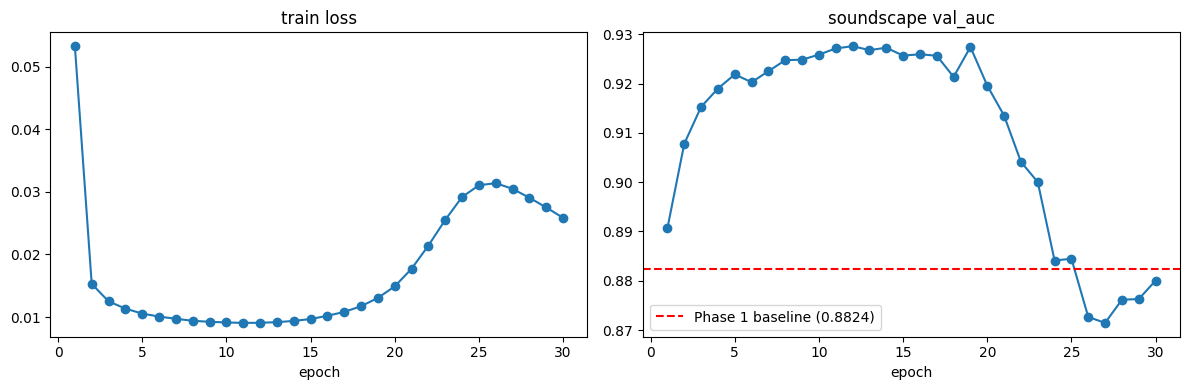

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for seed, hist in all_history.items():
    ep, loss, auc = zip(*hist)
    axes[0].plot(ep, loss, alpha=0.6, label=f"seed {seed}")
    axes[1].plot(ep, auc,  alpha=0.6, label=f"seed {seed}")
axes[0].set_title("train loss (per seed)"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("soundscape val_auc (per seed)"); axes[1].set_xlabel("epoch")
axes[1].axhline(0.9276, color="r", linestyle="--", label="Phase 3 baseline (0.9276)")
axes[1].axhline(0.9358, color="g", linestyle="--", label="Exp 4 (seed 42) 0.9358")
axes[1].axhline(ensemble_auc, color="purple", linestyle="-", linewidth=2,
                label=f"Ensemble {ensemble_auc:.4f}")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## What's next

If ensemble_auc > 0.9358 (Exp 4 single-seed best), this is the final Phase 3.5 model.

I'll then:
1. Copy all 5 `model_v5_seed*.pt` files to the Kaggle dataset.
2. Update the Kaggle kernel to load all 5 heads and average their logits.
3. Submit.

Expected LB: with val_auc improvement of ~+0.01 from ensembling, LB should land around **0.84-0.86**.

After Phase 3.5 ships, the next big lever is **Phase 5 (pseudo-labeling on unlabeled soundscapes)** — that's where the next +0.03-0.05 lives.
